In [1]:
import h5py
import pygmt
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
def to_xarray(data, x, y, key='z'):
    """Converts a 2D numpy array to an xarray.DataArray"""
    return xr.DataArray(data.T, coords=[y, x], dims=[ "lat", "lon"], name=key)

In [13]:
with h5py.File('OUTPUT_FILES/final_model.h5') as f:
    vs = f['vs'][:]
    theta = f['theta'][:]
    g0 = f['G0'][:]
    gc = f['Gc'][:]
    gs = f['Gs'][:]
    lon = f['lon'][:]
    lat = f['lat'][:]
    depths = f['dep'][:]
lonmin, lonmax = np.min(lon), np.max(lon)
latmin, latmax = np.min(lat), np.max(lat)
print(lonmin, lonmax, latmin, latmax)
with h5py.File('OUTPUT_FILES/model_iter.h5') as f:
    print(f.keys())
    init = f['vs_000'][:]
dv = (vs - init) / init * 100

with h5py.File('target_model.h5') as f:
    tvs = f['vs'][:]
    tgc = f['Gc'][:]
    tgs = f['Gs'][:]
    tg0 = f['G0'][:]
    ttheta = f['theta'][:]
tdv = (tvs - init) / init * 100

102.05000000223518 103.94999995976687 24.050000002235173 25.949999959766863
<KeysViewHDF5 ['dep', 'gc_000', 'gc_001', 'gc_002', 'gc_003', 'gc_004', 'gc_005', 'gc_006', 'gc_007', 'gc_008', 'gc_009', 'gc_010', 'gc_011', 'gc_012', 'gc_013', 'gc_014', 'gc_015', 'gc_016', 'gc_017', 'gc_018', 'gc_019', 'gc_020', 'gc_021', 'gc_022', 'gc_023', 'gc_024', 'gc_025', 'gc_026', 'gc_027', 'gc_028', 'gc_029', 'gc_030', 'gc_031', 'gc_032', 'gc_033', 'gc_034', 'gc_035', 'gc_036', 'gc_037', 'gc_038', 'gc_039', 'gc_040', 'gradient_gc_000', 'gradient_gc_001', 'gradient_gc_002', 'gradient_gc_003', 'gradient_gc_004', 'gradient_gc_005', 'gradient_gc_006', 'gradient_gc_007', 'gradient_gc_008', 'gradient_gc_009', 'gradient_gc_010', 'gradient_gc_011', 'gradient_gc_012', 'gradient_gc_013', 'gradient_gc_014', 'gradient_gc_015', 'gradient_gc_016', 'gradient_gc_017', 'gradient_gc_018', 'gradient_gc_019', 'gradient_gc_020', 'gradient_gc_021', 'gradient_gc_022', 'gradient_gc_023', 'gradient_gc_024', 'gradient_gc_025'

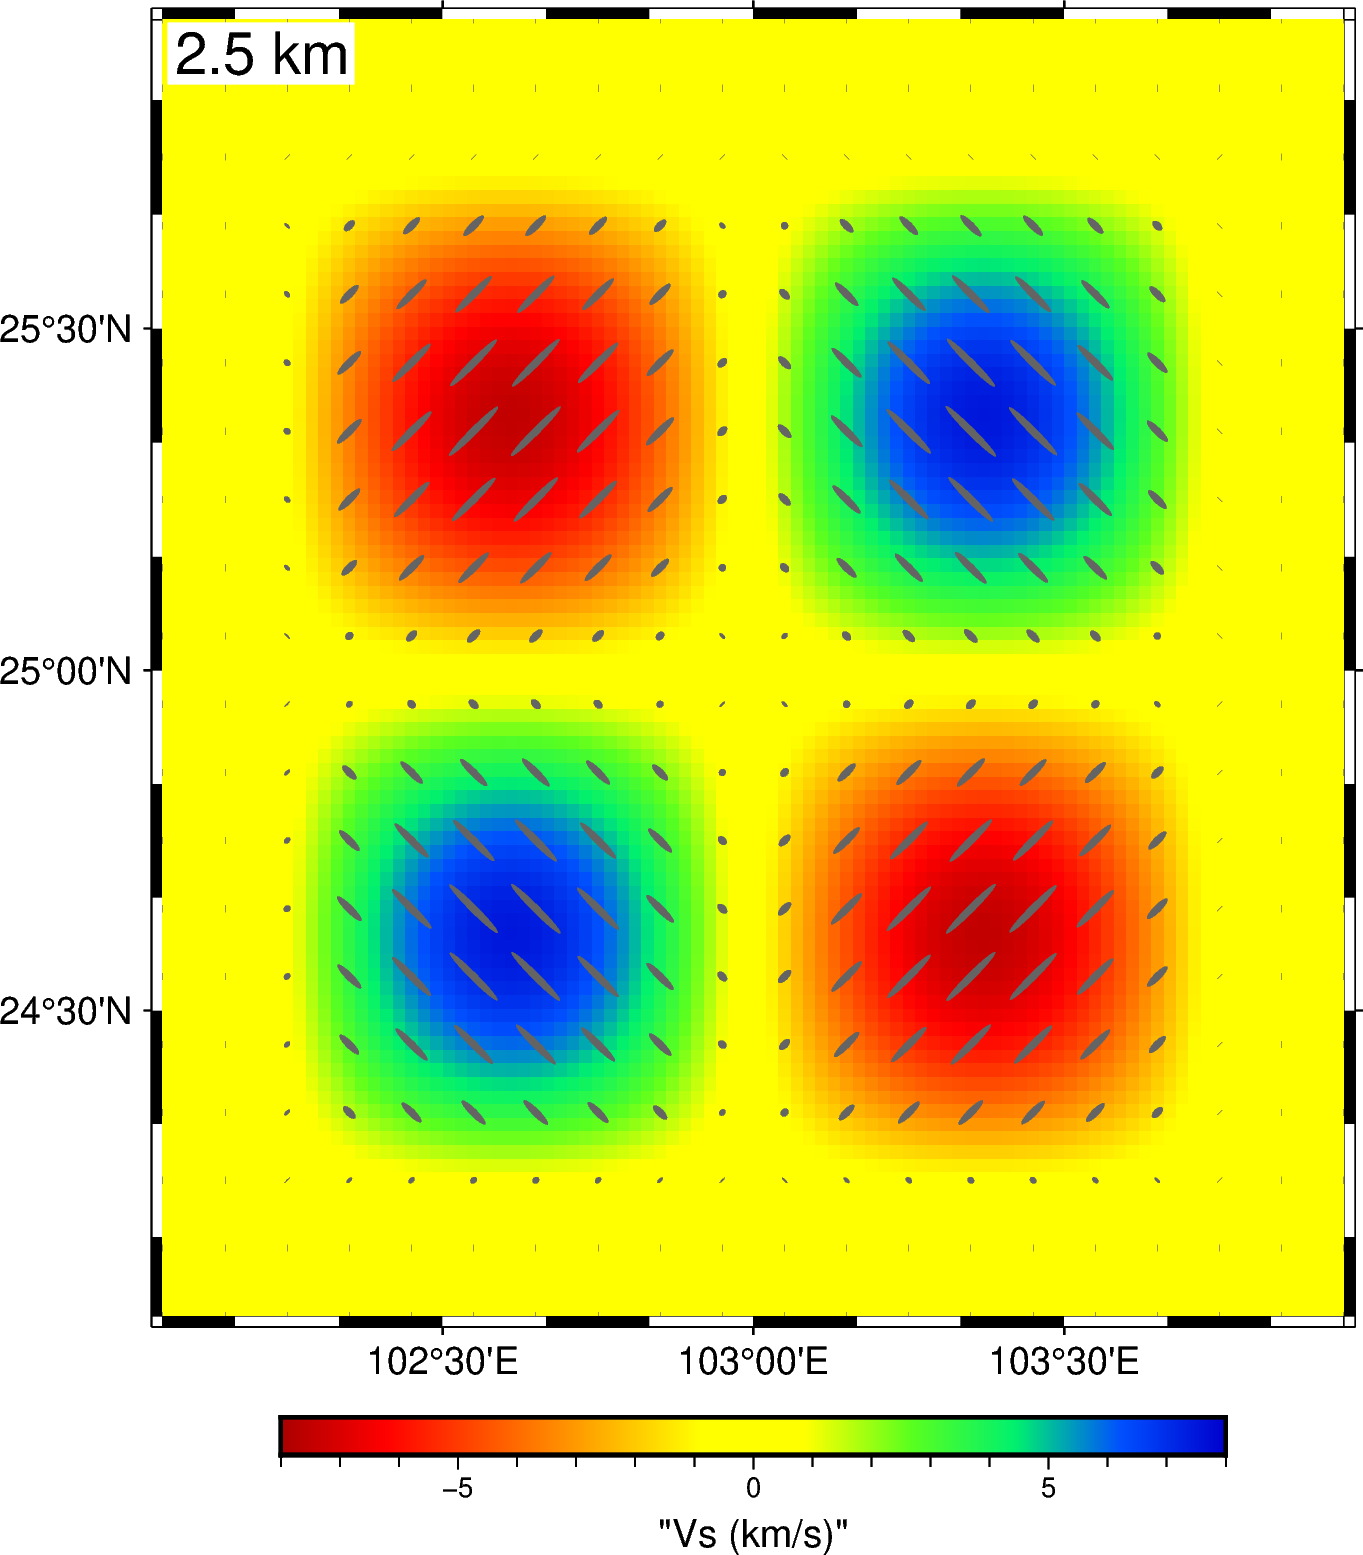

In [4]:
# Plot the true model
dep = 5
dn = 5
region = [lonmin, lonmax, latmin, latmax]
# grid_vs = pygmt.surface(data=data1[:, [0,1,3]], region=region, spacing='0.02/0.02')
grid_vs = to_xarray(tdv[:,:,int(dep)], lon, lat)
grid_g0 = to_xarray(tg0[:,:,int(dep)], lon, lat)
grid_g0_samp = to_xarray(tg0[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
grid_theta = to_xarray(ttheta[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
xyz_theta = pygmt.grd2xyz(grid_theta)
xyz_g0 = pygmt.grd2xyz(grid_g0_samp)
ani = pd.concat([xyz_theta['lon'], xyz_theta['lat'], xyz_theta['z'], xyz_g0['z']*8], axis=1)
# ani = pd.concat([xyz_gc['lon'], xyz_gc['lat'], theta, g0*8], axis=1)
ani['minax'] = np.ones_like(ani['lon'])*0.06
fig = pygmt.Figure()
fig.basemap(region=region, projection='M10c', frame=True)
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.grdimage(grid_vs, cmap=True)
fig.plot(ani, style='e',  fill='100')
fig.text(text=f'{depths[dep]} km', x=region[0], y=region[3], font='14p', justify='TL', no_clip=True, offset='0.1c/-0.1c', fill='255')
fig.colorbar(frame='af+l"Vs (km/s)"')
fig.show()

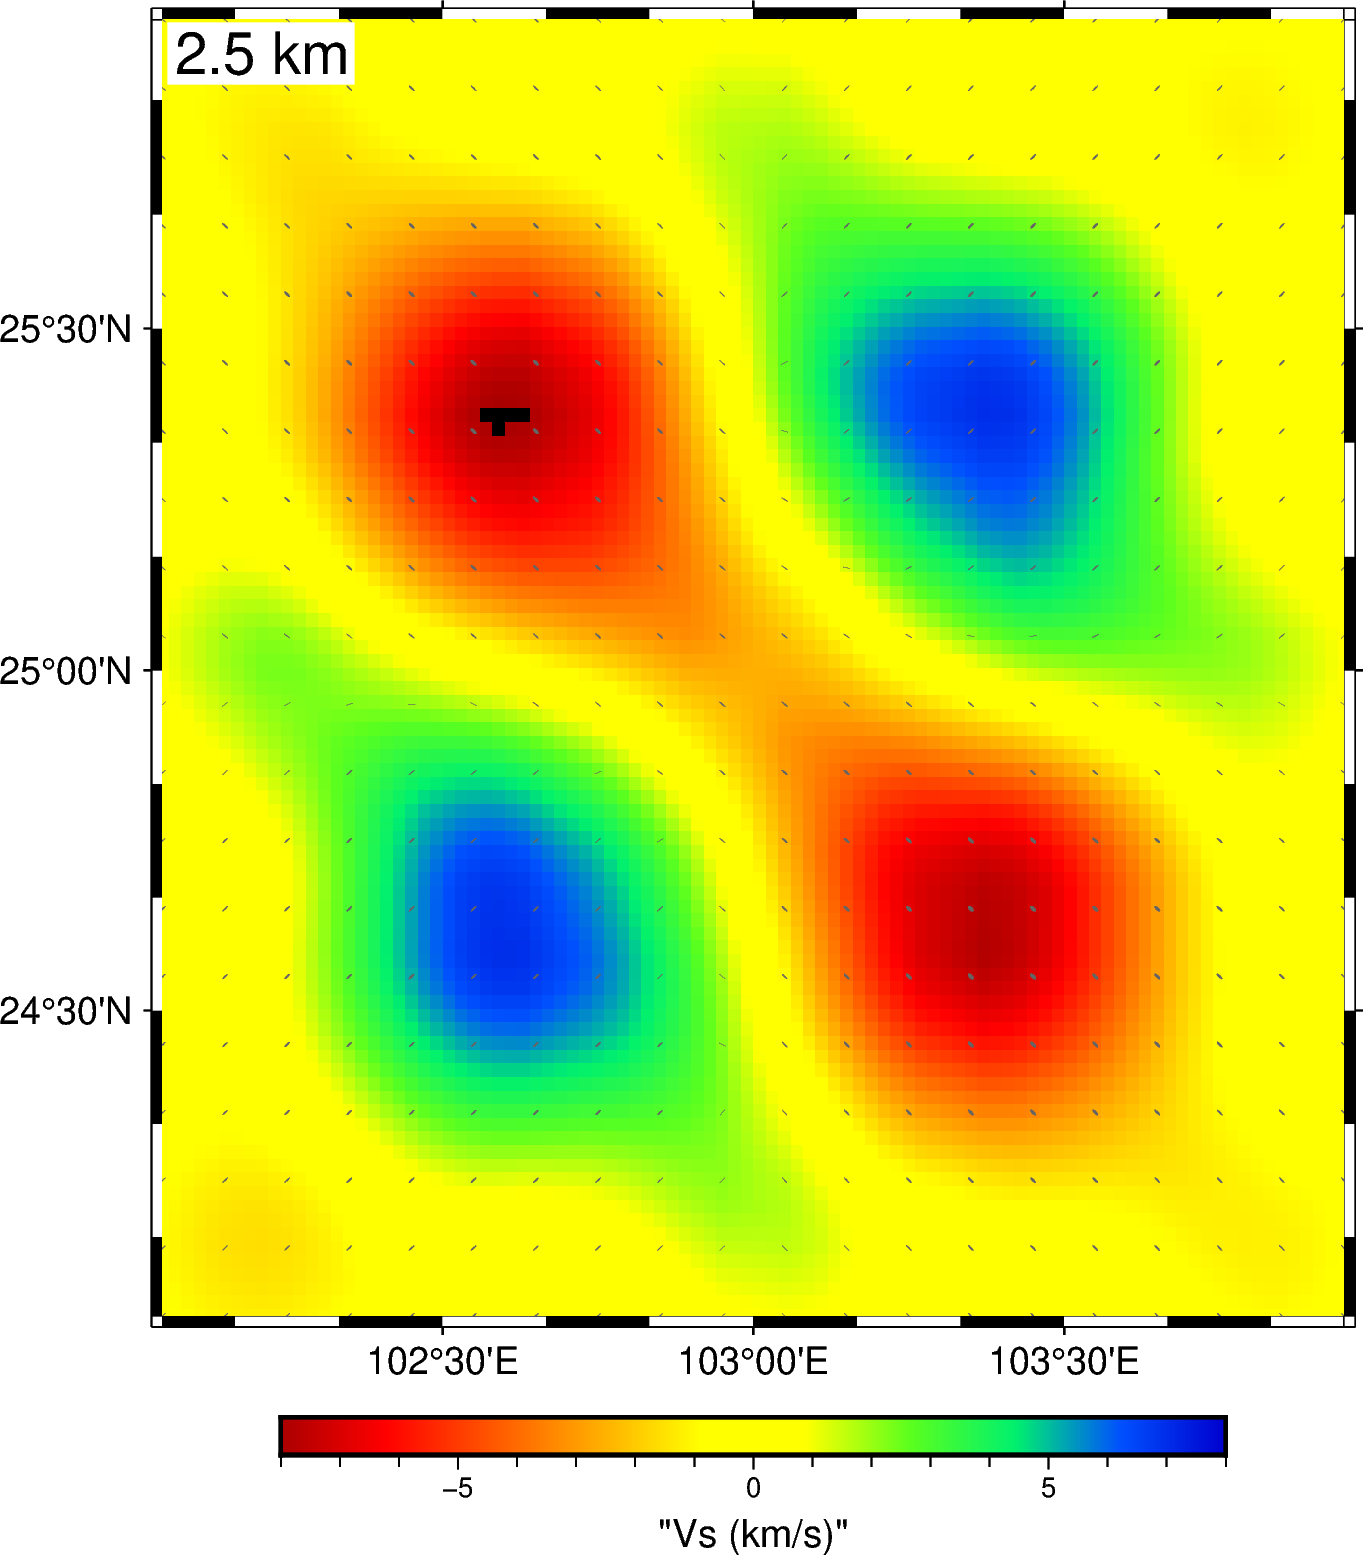

In [ ]:
# Plot the inverted model
dep = 5
dn = 5
region = [lonmin, lonmax, latmin, latmax]
# grid_vs = pygmt.surface(data=data1[:, [0,1,3]], region=region, spacing='0.02/0.02')
grid_vs = to_xarray(dv[:,:,int(dep)], lon, lat)
grid_g0 = to_xarray(g0[:,:,int(dep)], lon, lat)
grid_g0_samp = to_xarray(g0[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
grid_theta = to_xarray(theta[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
xyz_theta = pygmt.grd2xyz(grid_theta)
xyz_g0 = pygmt.grd2xyz(grid_g0_samp)
ani = pd.concat([xyz_theta['lon'], xyz_theta['lat'], xyz_theta['z'], xyz_g0['z']*8], axis=1)
# ani = pd.concat([xyz_gc['lon'], xyz_gc['lat'], theta, g0*8], axis=1)
ani['minax'] = np.ones_like(ani['lon'])*0.06
fig = pygmt.Figure()
fig.basemap(region=region, projection='M10c', frame=True)
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.grdimage(grid_vs, cmap=True)
fig.plot(ani, style='e',  fill='100')
fig.text(text=f'{depths[dep]} km', x=region[0], y=region[3], font='14p', justify='TL', no_clip=True, offset='0.1c/-0.1c', fill='255')
fig.colorbar(frame='af+l"Vs (km/s)"')
fig.show()